# Which polynomial terms survive as the decision-boundary surrogate is de-regularized?

Produces the regularization-path figures for the polynomial logistic-regression
surrogate of the XY decision boundary, described in the appendix "Fitting the decision
boundary" (`app:dec_bound_log_reg_fit`):

| file | manuscript figure |
|---|---|
| `Plots/optpath_seed46.pdf` | `fig:logreg_regpath`: one trained network, error bars over the 5 inner LogReg/CV seeds |
| `optpath_modelseed_avg.pdf` | `fig:logreg_regpath_averaged`: mean $\pm$ std over 5 independently trained networks |

### The question

The XY bottleneck is three-dimensional (the three active branches identified in the
main text's Fig. 4(e)-(f): a $1\times1$, a $2\times1$, and a $2\times2$ branch), so
unlike the Ising case its decision boundary is a surface rather than a single
threshold. To read off which physical observables that surface actually depends on,
the main text fits a degree-2 polynomial logistic-regression surrogate to TetrisCNN's
own predicted labels, then examines which polynomial terms an $L_1$-regularized fit
keeps as the regularization is relaxed.

Labeling the three branch activations $z_1, z_2, z_3$ in ranked order of mean $|z|$
(the plotting convention used below), the physical finding is that only four terms of
the possible nine ever matter: $z_1^2$, $z_1$, $z_2$, and $z_3$. No term from the two
smaller branches is squared, and no cross-term between branches survives. That this
holds both for one trained network (Fig. 22) and, averaged, across five independent
initializations (Fig. 23) is what licenses the main text's linear and quadratic
decision-boundary approximations: the functional form is a property of the task and
the data, not an artifact of one training run.

### What it reads

`Plots_data/XY_XZ_C4_smallkernels_lam3_seed{42..46}_p2`: the five independently
initialized $C_4$-equivariant XY runs (combined X+Z bases, $\lambda_{\max}=3$,
partition 2), per `Plots_data/README.md`. As in `Figure5.ipynb`, reconstructing
snapshots from these runs also requires the experimental `data/` tree, which is not
distributed with the repository. Everything here is fitted on the **training** split
(`FIT_SPLIT="train"`), exactly as the original `Figures5_6_combined_pipeline.ipynb`.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import torch
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from torch.utils.data import DataLoader

from tetriscnn.datasets import create_datasets
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import AttrDict, DEVICE, load_json, logistic_penalty_kwargs

from tetriscnn.colors import COLORS, colors

import re

plt.style.use(PAPER_MPLSTYLE)          # LaTeX manuscript style (text.usetex = True)

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Configuration

`MODEL_SEEDS` are the trained-network seeds; `CHOSEN_SEED` is the one drawn on its own in
figure 1. `SWEEP_SEEDS` is the inner LogReg / CV seed axis, `cs_tmp` / `deg` / `SEED` /
`VAR_NAMES` / `FIT_SPLIT` are copied verbatim from `Figures5_6_combined_pipeline.ipynb` cells 3 and
15. The width constants match the other `FigureN` notebooks.

In [2]:
MODEL_SEEDS   = [42, 43, 44, 45, 46]
CHOSEN_SEED   = 46                          # the single network shown in figure 1
BASEPATH_TMPL = "Plots_data/XY_XZ_C4_smallkernels_lam3_seed{seed}_p2"

FIT_SPLIT = "train"
N_DIMS    = 3
VAR_NAMES = ["X", "Y", "Z"]
SEED      = 0                               # default seed for fit_surface's signature

deg         = 2
SWEEP_SEEDS = range(5)                      # inner LogReg / CV random_state axis
cs_tmp = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1,
          5e-1, 1.0, 5, 10.0, 50, 100.0, 500, np.inf]

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
GOLDEN = (1 + np.sqrt(5)) / 2

OUTDIR = Path("Plots")
OUTDIR.mkdir(exist_ok=True)

for s in MODEL_SEEDS:
    p = Path(BASEPATH_TMPL.format(seed=s))
    print(f"seed {s}: {p}  exists={p.exists()}")

seed 42: Plots_data/XY_XZ_C4_smallkernels_lam3_seed42_p2  exists=True
seed 43: Plots_data/XY_XZ_C4_smallkernels_lam3_seed43_p2  exists=True
seed 44: Plots_data/XY_XZ_C4_smallkernels_lam3_seed44_p2  exists=True
seed 45: Plots_data/XY_XZ_C4_smallkernels_lam3_seed45_p2  exists=True
seed 46: Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2  exists=True


## Run loader

`load_run` and `active_branches` copied verbatim from `Figures5_6_combined_pipeline.ipynb` cell 5
(docstrings trimmed). One `DataLoader` pass, `shuffle=False`, so activations and logits
align index-for-index.

In [3]:
def load_run(run_folder: Path, split: str = "train"):
    """Config + weights from a run folder, with one split pushed through the net."""
    cf = AttrDict()
    cf.update(load_json(str(run_folder), "config.json"))

    for k in range(len(cf.kernels)):                # legacy runs lack a stride entry
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    cf.logdir = cf.seed_folder = str(run_folder)
    cf.return_all_data = False

    train_ds, val_ds = create_datasets(cf)
    dataset = {"train": train_ds, "val": val_ds}[split]

    net1 = ShapeAdaptiveConvNet(
        in_channels=dataset[0][0].shape[0], kernels=cf.kernels,
        equivariant=cf.equivariant, hidden_size=cf.hidden_size,
        init=cf.init, device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel([len(cf.kernels), 32, 16, dataset.output_dim],
                      device=DEVICE).to(DEVICE)
    net1.load_state_dict(torch.load(run_folder / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(run_folder / "net2.pt", map_location=DEVICE))
    net1.eval(); net2.eval()

    loader = DataLoader(dataset, batch_size=len(dataset), shuffle=False)
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            z = net1(x)
            out = net2(z)

    return {"cf": cf, "path": run_folder, "split": split,
            "x": x.cpu().numpy(), "z": z.cpu().numpy(), "out": out.cpu().numpy(),
            "group": cf.equivariant_group if getattr(cf, "equivariant", False) else None,
            "channels": ["X", "Z"] if x.shape[1] == 2 else ["Z"]}


def active_branches(z, abs_tol=1e-3, rel_tol=1e-3):
    """Branch indices the L1 penalty did not kill (a dead branch has zero variance)."""
    mags = np.abs(z).mean(axis=0)
    cut = max(abs_tol, rel_tol * mags.max())
    return [k for k in range(z.shape[1]) if mags[k] > cut]

## The boundary fitter

`boundary_expr` and `fit_surface` copied verbatim from `Figures5_6_combined_pipeline.ipynb`
cell 13. Per `(C, seed)` fit it returns the pipeline plus in-sample and 5-fold CV
accuracy; per-term coefficients are read off afterwards in **standardized** coordinates.

In [4]:
_TOKEN = re.compile(r"^([A-Z])(?:\^(\d+))?$")


def boundary_expr(scaler, clf, feat_names, var_names) -> sp.Expr:
    """The exact decision polynomial F(...) in ORIGINAL (unscaled) coordinates."""
    syms = sp.symbols(" ".join(var_names), real=True)
    syms = (syms,) if isinstance(syms, sp.Symbol) else tuple(syms)
    scaled = {name: (s - float(m)) / float(sd)
              for name, s, m, sd in zip(var_names, syms, scaler.mean_, scaler.scale_)}
    expr = sp.Float(float(clf.intercept_[0]))
    for fname, coef in zip(feat_names, clf.coef_[0]):
        if abs(coef) < 1e-12:
            continue
        term = sp.Float(float(coef))
        for tok in fname.split():
            var, power = _TOKEN.match(tok).groups()
            term *= scaled[var] ** (int(power) if power else 1)
        expr += term
    return expr


def fit_surface(X, y, degree=2, C_=0.04, penalty="l1", n_splits=5, seed=SEED,
                var_names=None):
    """Polynomial logistic boundary; in-sample and cross-validated accuracy."""
    var_names = var_names or VAR_NAMES[:X.shape[1]]
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LogisticRegression(**logistic_penalty_kwargs(penalty == "l1"), C=C_,
                           solver="liblinear" if penalty == "l1" else "lbfgs",
                           max_iter=20000, class_weight="balanced", random_state=seed),
    )
    pipe.fit(X, y)
    feat_names = pipe.named_steps["polynomialfeatures"].get_feature_names_out(var_names)
    coefs = pipe.named_steps["logisticregression"].coef_[0]
    nonzero = [(n, float(c)) for n, c in zip(feat_names, coefs) if abs(c) > 1e-8]
    cv = cross_val_score(pipe, X, y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return {
        "pipe": pipe, "degree": degree, "C": C_, "penalty": penalty,
        "acc": float(pipe.score(X, y)), "cv_mean": float(cv.mean()),
        "cv_std": float(cv.std()), "n_terms": len(nonzero), "n_feats": len(feat_names),
        "terms": nonzero, "feat_names": list(feat_names), "var_names": var_names,
        "expr": boundary_expr(pipe.named_steps["standardscaler"],
                              pipe.named_steps["logisticregression"],
                              feat_names, var_names),
    }

## The double sweep: 5 model seeds × the C grid × 5 LogReg seeds

For each trained C4 network: pick `LATENT` = the 3 most-active surviving branches (ranked
by `mean|z|`, the rule from `Figures5_6_combined_pipeline.ipynb` cell 6), build the activation
matrix `Z` and the network's predicted class `Y_NET = out.argmax(1)`, and run the full
`cs_tmp × SWEEP_SEEDS` sweep. `LATENT_SHAPES` records which branch landed in each latent
slot per seed.

In [5]:
PATH_ROWS  = []   # one row per (model_seed, C, logreg_seed, term):  |coef|
SWEEP_ROWS = []   # one row per (model_seed, C, logreg_seed):        cv_mean, acc
LATENT_SHAPES = {}

n_fits = len(MODEL_SEEDS) * len(cs_tmp) * len(list(SWEEP_SEEDS))
done = 0
for m in MODEL_SEEDS:
    D = load_run(Path(BASEPATH_TMPL.format(seed=m)), split=FIT_SPLIT)
    cf, z = D["cf"], D["z"]
    mags = np.abs(z).mean(axis=0)
    ranked = sorted(active_branches(z), key=lambda k: -mags[k])
    LATENT = ranked[:N_DIMS]
    if len(LATENT) < N_DIMS:
        raise ValueError(f"seed {m}: only {len(LATENT)} active branches ({LATENT})")
    LATENT_SHAPES[m] = [(k, tuple(cf.kernels[k][0]), cf.kernels[k][3])
                        for k in LATENT]   # kernels[k][3] is the mask (may be None)

    Zm = np.column_stack([z[:, b] for b in LATENT])
    Ym = D["out"].argmax(axis=1)

    for c in cs_tmp:
        fit_c = 1e12 if np.isinf(c) else c
        for s in SWEEP_SEEDS:
            r = fit_surface(Zm, Ym, degree=deg, C_=fit_c, seed=s)
            SWEEP_ROWS.append({"model_seed": m, "C": c, "logreg_seed": s,
                               "cv_mean": r["cv_mean"], "acc": r["acc"],
                               "n_terms": r["n_terms"]})
            poly = r["pipe"].named_steps["polynomialfeatures"]
            clf = r["pipe"].named_steps["logisticregression"]
            for term, coef in zip(poly.get_feature_names_out(VAR_NAMES), clf.coef_[0]):
                PATH_ROWS.append({"model_seed": m, "C": c, "logreg_seed": s,
                                  "term": term, "magnitude": abs(float(coef))})
            done += 1
        print(f"[{done:>3}/{n_fits}] seed {m}  C={c:g}", flush=True)

PATH_ROWS  = pd.DataFrame(PATH_ROWS)
SWEEP_ROWS = pd.DataFrame(SWEEP_ROWS)
print(f"\ncollected {len(PATH_ROWS)} coef rows, {len(SWEEP_ROWS)} sweep rows")


 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.


[  5/375] seed 42  C=0.0001


[ 10/375] seed 42  C=0.0005


[ 15/375] seed 42  C=0.001


[ 20/375] seed 42  C=0.005


...

[360/375] seed 46  C=50


[365/375] seed 46  C=100


[370/375] seed 46  C=500


[375/375] seed 46  C=inf



collected 3375 coef rows, 375 sweep rows


### Checking that branch identity lines up across seeds

Before aggregating polynomial-term magnitudes across the five independently trained
networks, it is worth checking that "slot 1", "slot 2", "slot 3" name the same physical
correlator in every network. Branch indices are arbitrary: nothing forces two
independently initialized networks to grow their strongest branch in position 0. So
`LATENT_SHAPES` records, for each seed, the kernel shape and mask of the branch that
landed in each rank-ordered slot. If a row below were not constant across the five seed
columns, the cross-seed average in Fig. 23 would be silently mixing different
correlators.


In [6]:
# Latent-slot line-up across the 5 networks. If a row is not constant, the cross-seed
# average of the corresponding polynomial terms mixes different branches.
pd.DataFrame(
    {m: [f"idx{k} shape{shape} mask={mask}" for k, shape, mask in LATENT_SHAPES[m]]
     for m in MODEL_SEEDS},
    index=[f"slot {v}" for v in VAR_NAMES],
)

,42,43,44,45,46
slot X,"idx0 shape(1, 1) mask=None","idx0 shape(1, 1) mask=None","idx0 shape(1, 1) mask=None","idx0 shape(1, 1) mask=None","idx0 shape(1, 1) mask=None"
slot Y,"idx1 shape(2, 1) mask=None","idx1 shape(2, 1) mask=None","idx1 shape(2, 1) mask=None","idx1 shape(2, 1) mask=None","idx1 shape(2, 1) mask=None"
slot Z,"idx2 shape(2, 2) mask=[[1, 0], [0, 1]]","idx2 shape(2, 2) mask=[[1, 0], [0, 1]]","idx2 shape(2, 2) mask=[[1, 0], [0, 1]]","idx2 shape(2, 2) mask=[[1, 0], [0, 1]]","idx2 shape(2, 2) mask=[[1, 0], [0, 1]]"


## Aggregation

`PATH_ROWS` columns: `model_seed, C, logreg_seed, term, magnitude` ($= |\text{coef}|$ on
standardized features). `SWEEP_ROWS` columns: `model_seed, C, logreg_seed, cv_mean`.

- **`logreg_spread`** (one stage): reduce over `logreg_seed`, giving mean $\pm$ std over
  the 5 LogReg seeds for a single network. This is the original notebook's error bar.
- **`aggregate_paths`** (two stages): (1) mean over `logreg_seed` per
  `(model_seed, C, term)`; (2) mean and std (`ddof=1`) over `model_seed` per `(C, term)`.
  Collapsing the LogReg axis first keeps LogReg noise out of the across-network spread.

The CV panels are reduced the same way (`cv_std` column in both cases).


In [7]:
def logreg_spread(path_rows: pd.DataFrame) -> pd.DataFrame:
    """One-stage: mean +/- std of |coef| over logreg_seed, per (C, term)."""
    return (path_rows.groupby(["C", "term"])["magnitude"]
            .agg(magnitude="mean", magnitude_std="std")
            .reset_index())


def aggregate_paths(path_rows: pd.DataFrame) -> pd.DataFrame:
    """Two-stage: LogReg-seed mean per model seed, then mean +/- std across model seeds."""
    per_seed = (path_rows.groupby(["model_seed", "C", "term"], as_index=False)["magnitude"]
                .mean())                                   # stage 1: over logreg_seed
    return (per_seed.groupby(["C", "term"])["magnitude"]
            .agg(magnitude="mean", magnitude_std="std")    # stage 2: over model_seed
            .reset_index())


def sweep_spread(sweep_rows: pd.DataFrame) -> pd.DataFrame:
    """One-stage CV panel: mean +/- std of cv_mean over logreg_seed, per C."""
    return (sweep_rows.groupby("C")["cv_mean"]
            .agg(cv_mean="mean", cv_std="std")
            .reset_index().rename(columns={"C": "C_requested"}))


def aggregate_sweep(sweep_rows: pd.DataFrame) -> pd.DataFrame:
    """Two-stage CV panel: LogReg-seed mean per model seed, then across model seeds."""
    per_seed = (sweep_rows.groupby(["model_seed", "C"], as_index=False)["cv_mean"].mean())
    return (per_seed.groupby("C")["cv_mean"]
            .agg(cv_mean="mean", cv_std="std")
            .reset_index().rename(columns={"C": "C_requested"}))


# --- figure 1: one chosen network, error bars over the 5 LogReg seeds -----------------
ONE = PATH_ROWS["model_seed"] == CHOSEN_SEED
PATH_SINGLE  = logreg_spread(PATH_ROWS[ONE])
SWEEP_SINGLE = sweep_spread(SWEEP_ROWS[SWEEP_ROWS["model_seed"] == CHOSEN_SEED])

# --- figure 2: mean +/- std across the 5 model seeds ---------------------------------
PATH_MEAN  = aggregate_paths(PATH_ROWS)
SWEEP_MEAN = aggregate_sweep(SWEEP_ROWS)

PATH_MEAN.head(12)

,C,term,magnitude,magnitude_std
0,0.0001,X,0.0,0.0
1,0.0001,X Y,0.0,0.0
2,0.0001,X Z,0.0,0.0
3,0.0001,X^2,0.0,0.0
4,0.0001,Y,0.0,0.0
5,0.0001,Y Z,0.0,0.0
6,0.0001,Y^2,0.0,0.0
7,0.0001,Z,0.0,0.0
8,0.0001,Z^2,0.0,0.0
9,0.0005,X,0.0,0.0


## Plotting

`plot_optpath` is `Figures5_6_combined_pipeline.ipynb` cell 16, restyled: `paper.mplstyle`
typography, `colors` cycle for the term lines, `COLORS` for the CV panel, LaTeX term
labels, `DOUBLE_WIDTH` figure, and a saved PDF. `C = ∞` sits at `3 × max(finite C)` on
the log axis.

In [8]:
TERM_ORDER = list(
    PolynomialFeatures(degree=deg, include_bias=False)
    .fit(np.zeros((1, N_DIMS)))
    .get_feature_names_out(VAR_NAMES)
)
_FINITE_CS = [c for c in cs_tmp if np.isfinite(c)]
INF_X = max(_FINITE_CS) * 3
X_POS = {c: (INF_X if np.isinf(c) else c) for c in cs_tmp}


def term_latex(name):
    """'X' -> $z_{1}$, 'X^2' -> $z_{1}^{2}$, 'X Y' -> $z_{1}z_{2}$."""
    indices = {"X": 1, "Y": 2, "Z": 3}
    out = []
    for tok in name.split():
        v, p = re.match(r"^([A-Z])(?:\^(\d+))?$", tok).groups()
        base = rf"z_{{{indices[v]}}}"
        out.append(base if p is None else rf"{base}^{{{p}}}")
    return "$" + "".join(out) + "$"


def plot_optpath(path_mean, sweep_mean, *, title, band_label, fname=None, cv_ylim=None):
    """Stylised copy of Figures5_6_combined_pipeline cell 16: the degree-2 optimisation path."""
    fig, axs = plt.subplots(
        2, 1, figsize=(SINGLE_WIDTH, SINGLE_WIDTH / GOLDEN * 1.2),
        sharex=True, gridspec_kw={"height_ratios": [4, 1]})

    ax = axs[0]
    for i, term in enumerate(TERM_ORDER):
        p = path_mean[path_mean["term"] == term].copy()
        if p.empty:
            continue
        p["x"] = p["C"].map(X_POS)
        p = p.sort_values("x")
        ax.errorbar(p["x"], p["magnitude"], yerr=p["magnitude_std"],
                    marker="o", color=colors[i % len(colors)],
                    capsize=1.5, elinewidth=0.6, label=term_latex(term))
    ax.set_xscale("log")
    ax.set_ylabel(r"mean $|\mathrm{coef}|$")
    ax.set_title(title)
    ax.legend(ncol=3, loc="upper left")

    ax = axs[1]
    s = sweep_mean.copy()
    s["x"] = s["C_requested"].map(X_POS)
    s = s.sort_values("x")
    ax.plot(s["x"], s["cv_mean"], marker="o", color=COLORS["blackish"])
    ax.fill_between(s["x"], s["cv_mean"] - s["cv_std"], s["cv_mean"] + s["cv_std"],
                    alpha=0.25, color=COLORS["blue"], label=band_label)
    ax.set_xscale("log")
    ax.set_xlabel(r"$C$ (inverse $L_1$ penalty)")
    ax.set_ylabel("CV acc.")
    if cv_ylim:
        ax.set_ylim(*cv_ylim)
    ax.legend(loc="lower right")
    ax.set_xticks(list(X_POS.values()))
    # ax.set_xticklabels([f"{c:g}" if np.isfinite(c) else r"$\infty$" for c in cs_tmp],
    ax.set_xticklabels([f"{c:g}" if np.isfinite(c) else "unconstrained" for c in cs_tmp],
                       rotation=45, ha="right")

    if fname:
        fig.savefig(OUTDIR / fname)
        print(f"wrote {OUTDIR / fname}")
    return fig

### Reading Fig. 22: one trained network

`plot_optpath` draws the coefficient magnitude of each polynomial term against $C$
(top panel) and the corresponding five-fold cross-validation accuracy of the surrogate
(bottom panel), for the single network at `CHOSEN_SEED=46` used throughout the main
text. Error bars are $\pm1$ standard deviation over the five inner LogReg/CV seeds, not
over independent networks: this is the original `Figures5_6_combined_pipeline.ipynb` plot,
restyled for the manuscript.

As $C$ grows (regularization relaxes, moving right), more polynomial terms acquire
nonzero coefficients, but only four of them, $z_1^2$, $z_1$, $z_2$, and $z_3$, grow to
appreciable magnitude and stay there; the remaining five terms (the other two squares
and all three cross-terms) stay near zero throughout. The lower panel shows this
sparsity is not merely tolerated but rewarded: cross-validation accuracy is essentially
flat once those four terms are available, so the extra terms an unconstrained fit would
add do not buy additional predictive power. $C=10^{-4}$ collapses the surrogate to
chance and is clipped off the accuracy panel by design (`cv_ylim`).


wrote Plots/optpath_seed46.pdf


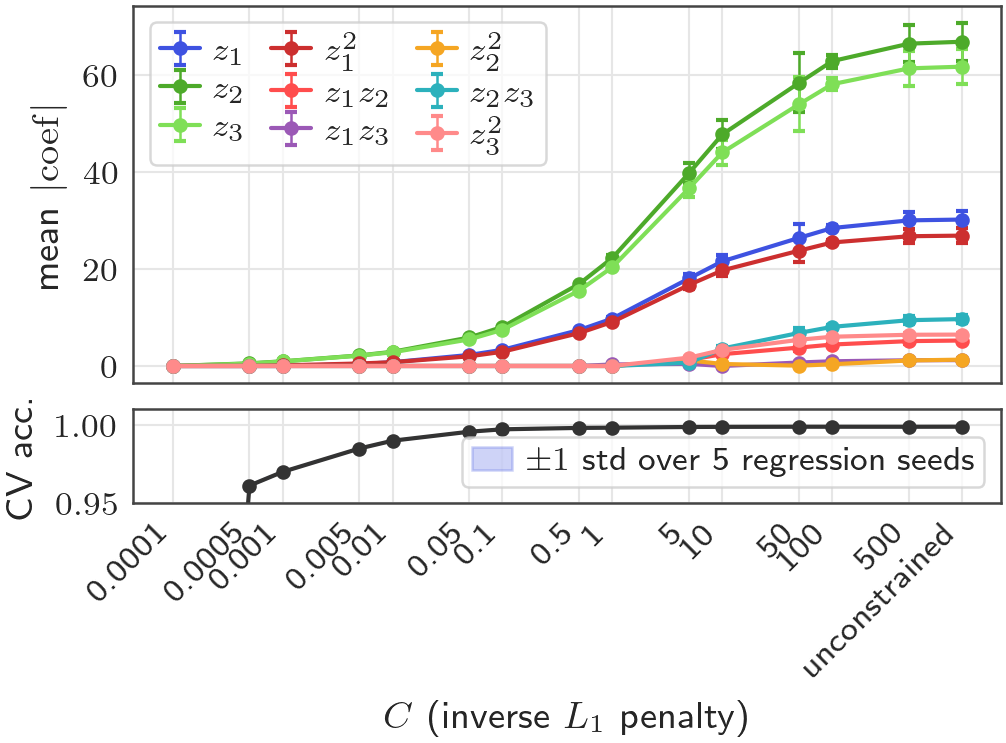

In [9]:
fig1 = plot_optpath(
    PATH_SINGLE, SWEEP_SINGLE,
    #       rf"($\lambda_{{\max}}=3$ C4, seed {CHOSEN_SEED})",
    title="",
    band_label=r"$\pm 1$ std over 5 regression seeds",
    fname=f"optpath_seed{CHOSEN_SEED}.pdf",
    cv_ylim=(0.95, 1.01),   # C = 1e-4 collapses to chance and clips off-panel by design
)

### Reading Fig. 23: stability across independently trained networks

The same plot, but each point is now a mean over the five independently initialized
$C_4$ networks (seeds 42-46), with the band showing $\pm1$ standard deviation across
networks rather than across LogReg/CV seeds. This aggregation is only meaningful
because the branch-identity check above confirms that $z_1, z_2, z_3$ name the same
physical branch, in the same rank order, across all five networks.

The same four terms dominate here as in Fig. 22, and the cross-validation accuracy
follows the same shape. This is the evidence behind the manuscript's claim
(`fig:logreg_regpath_averaged`) that the inferred functional form of the decision
boundary does not depend on which random initialization produced the network.


wrote Plots/optpath_modelseed_avg.pdf


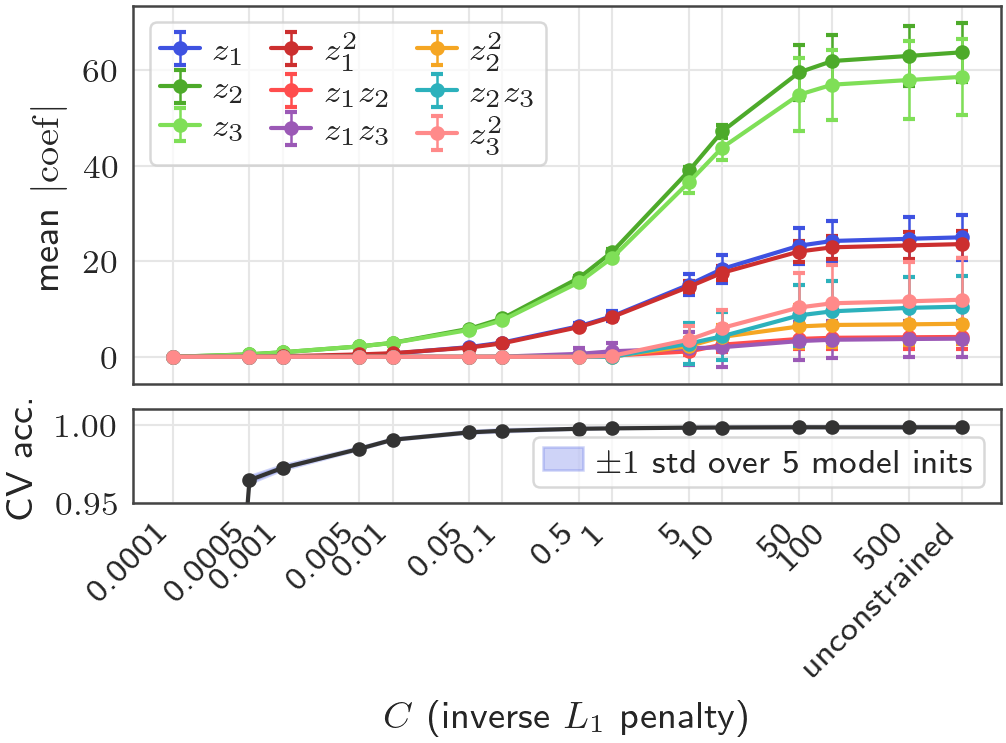

In [10]:
fig2 = plot_optpath(
    PATH_MEAN, SWEEP_MEAN,
        #   rf"(mean $\pm$ std over {len(MODEL_SEEDS)} C4 model inits)",
    title="",
    band_label=rf"$\pm 1$ std over {len(MODEL_SEEDS)} model inits",
    fname="optpath_modelseed_avg.pdf",
    cv_ylim=(0.95, 1.01),   # same window as figure 1; C = 1e-4 clips off-panel by design
)